# Segmentation Evaluation Pipeline

Loads saved models and scores them against train, validation and test splits using
the same metrics as the training notebooks.

Handles multiple datasets in one pass, and both single-split models and K-fold
artefacts (individual folds and the averaged ensembles), picking a defensible
validation set for each.


## Configuration

Everything you need to change lives in this cell. The dataset table mirrors
`DATASET_CONFIGS` in the training notebooks, so keep the two in sync. List every
dataset you want scored in `DATASETS_TO_EVALUATE`.


In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
import os

# Pin the GPU BEFORE tensorflow is imported, or the setting is ignored.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Datasets are evaluated one at a time and freed in between, so adding more
# here costs runtime but not peak memory.
DATASETS_TO_EVALUATE = ["KDSB", "ISIC2018"]

DATASET_CONFIGS = {
    "ISIC2018": {
        "train_path": "datasets/ISIC2018/train/",
        "val_path":   "datasets/ISIC2018/val/",
        "test_path":  "datasets/ISIC2018/test/",
        "mask_name":  lambda img_name: img_name,
    },
    "KDSB": {
        "train_path": "datasets/KDSB/train/",
        "val_path":   "datasets/KDSB/val/",
        "test_path":  "datasets/KDSB/test/",
        "mask_name":  lambda img_name: img_name,
    },
}

# ---- Paths ----
MODEL_DIR   = "saved_models"
SAVE_NP     = "saved_np"
RESULTS_DIR = "results"

# ---- Image geometry (must match training) ----
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = 256, 256, 3

# ---- Evaluation ----
THRESHOLD     = 0.5     # binarisation threshold
PREDICT_BATCH = 8       # lower if you hit OOM
EVAL_TRAIN    = True    # in-sample metrics, diagnostic only
EVAL_VAL      = True
EVAL_TEST     = True

# ---- Must match the training notebooks exactly ----
val_split       = 0.3
N_FOLDS         = 5
CV_RANDOM_STATE = 42

# ---- Which models to score ----
# None -> auto-discover per dataset. Or map dataset name to an explicit list:
#         MODELS_TO_EVALUATE = {"KDSB": ["model_KDSB_UNet_5pct_ensemble.keras"]}
MODELS_TO_EVALUATE = None

# When auto-discovering, restrict to these kinds: "ensemble", "fold", "single"
INCLUDE_KINDS = ["ensemble", "fold"]

# ---- Free each dataset's arrays after its models are scored ----
FREE_BETWEEN_DATASETS = True

os.makedirs(SAVE_NP, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

for name in DATASETS_TO_EVALUATE:
    if name not in DATASET_CONFIGS:
        raise KeyError(f"{name} is not in DATASET_CONFIGS")
    has_val = os.path.isdir(os.path.join(DATASET_CONFIGS[name]["val_path"], "org"))
    print(f"{name:10} val folder: {'yes' if has_val else 'no (will fall back to a slice)'}")


KDSB       val folder: yes
ISIC2018   val folder: yes


## Imports

In [2]:
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.io import imread
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from hausdorff import hausdorff_distance

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPUs visible:", [g.name for g in gpus] or "none, running on CPU")


I0000 00:00:1786924204.723755 3704435 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs visible: ['/physical_device:GPU:0']


## Data Loading

`load_dataset()` returns one dataset's arrays as a dict. It is called inside the
evaluation loop so only one dataset occupies memory at a time. Arrays are cached to
`saved_np/` using the same filenames the training notebooks write, so existing caches
are reused rather than rebuilt.


In [3]:
def load_split(split_path, split_name, mask_name_fn):
    """Load one split from disk, resized and binarised. Mirrors the training notebooks."""
    ids = sorted(next(os.walk(os.path.join(split_path, "org")))[2])
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(ids), total=len(ids), desc=split_name):
        img = imread(os.path.join(split_path, "org", id_))[:, :, :IMG_CHANNELS]
        X[n] = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode="constant", preserve_range=True)

        mask = imread(os.path.join(split_path, "gt", mask_name_fn(id_)))
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode="constant", preserve_range=True)
        Y[n][mask[:, :, 0] / 255 > 0.] = 1.

    return X, Y


def cached_split(dataset_name, split_path, split_name, mask_name_fn):
    """Load from saved_np/ if present, otherwise read from disk and cache."""
    xp = os.path.join(SAVE_NP, f"{dataset_name}_X_{split_name}_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
    yp = os.path.join(SAVE_NP, f"{dataset_name}_Y_{split_name}_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

    if os.path.exists(xp) and os.path.exists(yp):
        print(f"  {split_name}: cache")
        return np.load(xp), np.load(yp)

    print(f"  {split_name}: reading {split_path}")
    X, Y = load_split(split_path, split_name, mask_name_fn)
    np.save(xp, X)
    np.save(yp, Y)
    return X, Y


def load_dataset(dataset_name):
    """Return every array one dataset needs, as a dict."""
    cfg = DATASET_CONFIGS[dataset_name]
    mask_name_fn = cfg["mask_name"]
    has_val = os.path.isdir(os.path.join(cfg["val_path"], "org"))

    print(f"Loading {dataset_name}...")
    X_train, Y_train = cached_split(dataset_name, cfg["train_path"], "train", mask_name_fn)
    X_test,  Y_test  = cached_split(dataset_name, cfg["test_path"],  "test",  mask_name_fn)

    if has_val:
        X_val, Y_val = cached_split(dataset_name, cfg["val_path"], "val", mask_name_fn)
    else:
        X_val, Y_val = None, None

    print(f"  train={X_train.shape[0]}  "
          f"val={X_val.shape[0] if has_val else 'n/a'}  test={X_test.shape[0]}")

    return {
        "name": dataset_name, "has_val": has_val,
        "X_train": X_train, "Y_train": Y_train,
        "X_val": X_val,     "Y_val": Y_val,
        "X_test": X_test,   "Y_test": Y_test,
    }


## Metric Helpers

Identical to the training notebooks so numbers are directly comparable.

In [4]:
def iou_metric(y_true_in, y_pred_in):
    labels = label(y_true_in > 0.5)
    y_pred = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        prec.append(tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0)
    return np.mean(prec)


def iou_metric_batch(y_true_in, y_pred_in):
    return np.mean([iou_metric(y_true_in[b], y_pred_in[b]) for b in range(y_true_in.shape[0])])


def dice_coeff(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))


def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return np.mean([haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])])


def evalResult(gt, pred, num_class=2):
    """Same computation as the training notebooks; returns a metrics dict."""
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)

    acc = Accuracy();  acc.update_state(gt, pred); r_acc = acc.result().numpy()
    pr  = Precision(); pr.update_state(gt, pred);  r_pr  = pr.result().numpy()
    rc  = Recall();    rc.update_state(gt, pred);  r_rc  = rc.result().numpy()
    mi  = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()

    dc = np.mean([dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])])
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    r_mae = MeanAbsoluteError()(gt, pred).numpy()

    print(f"  Accuracy={r_acc:.4f}  Precision={r_pr:.4f}  Recall={r_rc:.4f}  "
          f"MeanIoU={r_mi:.4f}  Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")

    return {"Accuracy": r_acc, "Precision": r_pr, "Recall": r_rc, "MeanIoU": r_mi,
            "Dice": dc, "HD": hd, "MyIoU": miou, "MAE": r_mae}


## Model Discovery and Filename Parsing

Filenames follow `model_{DATASET}_{FAMILY}_{pct}pct[_fold{i}|_ensemble].keras`.
The parser tolerates a missing `.keras` extension and a missing dataset prefix,
which older runs sometimes produced.


In [5]:
MODEL_PATTERN = re.compile(
    r"^model_"
    r"(?:(?P<dataset>[A-Za-z0-9]+)_)??"
    r"(?P<family>BT-UNet|SimSiam-UNET|UNet)_"
    r"(?P<pct>\d+)pct"
    # Optional ablation variant. Lookaheads stop it swallowing a trailing
    # fold marker or "ensemble"; the lazy quantifier stops it swallowing
    # ".keras". Variants may not contain underscores.
    r"(?:_(?!fold\d+(?:\.keras)?$)(?!ensemble(?:\.keras)?$)(?P<variant>[A-Za-z0-9.\-]+?))?"
    r"(?:_fold(?P<fold>\d+)|_(?P<ensemble>ensemble))?"
    r"(?:\.keras)?$",
    re.IGNORECASE,
)

FAMILY_LABELS = {"bt-unet": "BT-UNet", "simsiam-unet": "SimSiam", "unet": "Baseline"}


def parse_model_name(filename):
    """Return a dict describing a model file, or None if the name doesn't match."""
    m = MODEL_PATTERN.match(os.path.basename(filename))
    if not m:
        return None

    kind = "ensemble" if m.group("ensemble") else ("fold" if m.group("fold") is not None else "single")
    return {
        "dataset":  m.group("dataset"),
        "family":   FAMILY_LABELS.get(m.group("family").lower(), m.group("family")),
        "pct":      int(m.group("pct")),
        "fraction": int(m.group("pct")) / 100.0,
        "variant":  m.group("variant"),
        "fold":     int(m.group("fold")) if m.group("fold") is not None else None,
        "kind":     kind,
    }


def discover_models(dataset_name):
    """Find every .keras file in MODEL_DIR belonging to one dataset."""
    found = []
    for path in sorted(glob.glob(os.path.join(MODEL_DIR, "*.keras"))):
        info = parse_model_name(path)
        if info is None:
            continue
        # Files with no dataset prefix are legacy; they can't be attributed, so skip.
        if not info["dataset"] or info["dataset"].lower() != dataset_name.lower():
            continue
        if info["kind"] not in INCLUDE_KINDS:
            continue
        found.append(os.path.basename(path))
    return found


def resolve_file(filename):
    """Return the on-disk filename, adding a missing .keras extension if needed."""
    if os.path.exists(os.path.join(MODEL_DIR, filename)):
        return filename
    if not filename.endswith(".keras") and os.path.exists(os.path.join(MODEL_DIR, filename + ".keras")):
        return filename + ".keras"
    return filename


def models_for(dataset_name):
    """Resolve which files to score for one dataset.

    MODELS_TO_EVALUATE may be None (auto-discover), a dict keyed by dataset, or a
    flat list. A flat list is filtered by the dataset encoded in each filename, so
    one combined list can cover every dataset without cross-contaminating them.
    """
    if MODELS_TO_EVALUATE is None:
        files = discover_models(dataset_name)
    elif isinstance(MODELS_TO_EVALUATE, dict):
        files = MODELS_TO_EVALUATE.get(dataset_name, [])
    else:
        files = []
        for f in MODELS_TO_EVALUATE:
            info = parse_model_name(f)
            if info is None:
                continue                      # reported later as unrecognised
            if info["dataset"] is None:
                continue                      # ambiguous without a dataset prefix
            if info["dataset"].lower() == dataset_name.lower():
                files.append(f)

    seen, ordered = set(), []
    for f in files:
        f = resolve_file(f)
        if f not in seen:
            seen.add(f)
            ordered.append(f)
    return ordered


def unroutable_entries():
    """Flat-list entries that no dataset will pick up, so they can be reported once."""
    if not isinstance(MODELS_TO_EVALUATE, list):
        return []
    wanted = {d.lower() for d in DATASETS_TO_EVALUATE}
    bad = []
    for f in MODELS_TO_EVALUATE:
        info = parse_model_name(f)
        if info is None:
            bad.append((f, "filename not recognised"))
        elif info["dataset"] is None:
            bad.append((f, "no dataset prefix, cannot be attributed"))
        elif info["dataset"].lower() not in wanted:
            bad.append((f, f"dataset '{info['dataset']}' not in DATASETS_TO_EVALUATE"))
    return bad


print("Queued per dataset:\n")
for ds in DATASETS_TO_EVALUATE:
    files = models_for(ds)
    print(f"{ds}  ({len(files)} model(s))")
    for f in files:
        info = parse_model_name(f)
        tag  = info["kind"] if info["fold"] is None else f"fold {info['fold']}"
        here = "   " if os.path.exists(os.path.join(MODEL_DIR, f)) else "  [missing on disk]"
        print(f"    {info['family']:9} {info['pct']:>3}%  ({tag}){here} {f}")
    if not files:
        print("    none found — check MODEL_DIR and INCLUDE_KINDS")
    print()

for f, why in unroutable_entries():
    print(f"[SKIP] {f}  <- {why}")


Queued per dataset:

KDSB  (72 model(s))
    BT-UNet    10%  (ensemble)    model_KDSB_BT-UNet_10pct_ensemble.keras
    BT-UNet    10%  (fold 0)    model_KDSB_BT-UNet_10pct_fold0.keras
    BT-UNet    10%  (fold 1)    model_KDSB_BT-UNet_10pct_fold1.keras
    BT-UNet    10%  (fold 2)    model_KDSB_BT-UNet_10pct_fold2.keras
    BT-UNet    10%  (fold 3)    model_KDSB_BT-UNet_10pct_fold3.keras
    BT-UNet    10%  (fold 4)    model_KDSB_BT-UNet_10pct_fold4.keras
    BT-UNet    20%  (ensemble)    model_KDSB_BT-UNet_20pct_ensemble.keras
    BT-UNet    20%  (fold 0)    model_KDSB_BT-UNet_20pct_fold0.keras
    BT-UNet    20%  (fold 1)    model_KDSB_BT-UNet_20pct_fold1.keras
    BT-UNet    20%  (fold 2)    model_KDSB_BT-UNet_20pct_fold2.keras
    BT-UNet    20%  (fold 3)    model_KDSB_BT-UNet_20pct_fold3.keras
    BT-UNet    20%  (fold 4)    model_KDSB_BT-UNet_20pct_fold4.keras
    BT-UNet    50%  (ensemble)    model_KDSB_BT-UNet_50pct_ensemble.keras
    BT-UNet    50%  (fold 0)    model_KDSB_BT-U

## Choosing a Validation Set

This is the part worth reading carefully, because "validation" means different
things for different artefacts.

**Single-split models** trained against the dedicated `val/` folder when one exists,
otherwise against the last `val_split` of their labelled subset. Either is reproduced
exactly here.

**Individual fold models** each held out one fold of the labelled subset. Re-running
`KFold` with the same `N_FOLDS` and `CV_RANDOM_STATE` reproduces that exact held-out
fold, so their validation scores are clean.

**Ensembles** are the awkward case. Averaging all five folds means every sample in the
labelled subset was in the training data of four of the five members. There is no
subset of the labelled data that the ensemble hasn't largely seen, so slicing one off
would produce an optimistic number, not a validation score.

When a `val/` folder exists it solves this outright: no fold ever touched it, so it is
genuinely held out for every artefact including ensembles. That is why the ensembles
get scored against the folder and not against a slice. Without one, the code still
reports a number but flags it as contaminated, and the external test set becomes the
only trustworthy signal.


In [6]:
def get_eval_splits(data, info):
    """Return (X_tr, Y_tr, X_va, Y_va, val_source) for one model of one dataset."""
    X_train, Y_train = data["X_train"], data["Y_train"]
    n_labelled = int(X_train.shape[0] * info["fraction"])
    X_subset   = X_train[:n_labelled]
    Y_subset   = Y_train[:n_labelled]

    def fold_train_idx():
        n_folds_this = min(N_FOLDS, X_subset.shape[0])
        kf = KFold(n_splits=n_folds_this, shuffle=True, random_state=CV_RANDOM_STATE)
        return list(kf.split(X_subset))[info["fold"]]

    # Validation: prefer the dedicated folder, it is clean for every artefact kind.
    if data["has_val"]:
        if info["kind"] == "fold":
            tr_idx, _ = fold_train_idx()
            X_tr, Y_tr = X_subset[tr_idx], Y_subset[tr_idx]
        else:
            X_tr, Y_tr = X_subset, Y_subset
        return X_tr, Y_tr, data["X_val"], data["Y_val"], "val folder"

    # No val folder: reconstruct whatever the training notebook used.
    if info["kind"] == "fold":
        tr_idx, va_idx = fold_train_idx()
        return (X_subset[tr_idx], Y_subset[tr_idx],
                X_subset[va_idx], Y_subset[va_idx], "held-out fold")

    split_idx = int(n_labelled * (1 - val_split))
    # For ensembles every fold model saw most of this subset; reported for completeness.
    source = "CONTAMINATED slice" if info["kind"] == "ensemble" else "subset slice"
    return (X_subset[:split_idx], Y_subset[:split_idx],
            X_subset[split_idx:], Y_subset[split_idx:], source)


## Evaluation Loop

In [7]:
import gc

results = []

for dataset_name in DATASETS_TO_EVALUATE:

    model_files = models_for(dataset_name)
    if not model_files:
        print(f"\n### {dataset_name}: nothing to evaluate, skipping\n")
        continue

    print(f"\n{'#'*66}")
    print(f"# {dataset_name}  —  {len(model_files)} model(s)")
    print(f"{'#'*66}")

    data = load_dataset(dataset_name)

    for model_name in model_files:

        info = parse_model_name(model_name)
        if info is None:
            print(f"\n[SKIP] Unrecognised filename: {model_name}")
            continue

        model_path = os.path.join(MODEL_DIR, model_name)
        if not os.path.exists(model_path):
            print(f"\n[SKIP] Not found on disk: {model_path}")
            continue

        X_tr, Y_tr, X_va, Y_va, val_source = get_eval_splits(data, info)

        print(f"\n{'='*66}")
        print(f"{dataset_name}  {info['family']}  {info['pct']}%  ({info['kind']})")
        print(f"  train={X_tr.shape[0]}  val={X_va.shape[0]} [{val_source}]  test={data['X_test'].shape[0]}")
        print(f"{'='*66}")

        if val_source.startswith("CONTAMINATED"):
            print("  NOTE: no val folder, and every fold model trained on most of this")
            print("        subset. Treat the validation row as in-sample; use Test.")

        model = load_model(model_path, compile=False)

        row = {
            "Dataset":            dataset_name,
            "Model":              info["family"],
            "Variant":            info.get("variant") or "base",
            "Label Fraction (%)": info["pct"],
            "Kind":               info["kind"],
            "Fold":               info["fold"],
            "Val Source":         val_source,
            "File":               model_name,
        }

        if EVAL_TRAIN:
            print("\nTRAIN (in-sample)")
            preds = (model.predict(X_tr, batch_size=PREDICT_BATCH, verbose=0) > THRESHOLD).astype(np.float32)
            for k, v in evalResult(Y_tr.astype(np.float32), preds).items():
                row[f"Train {k}"] = v

        if EVAL_VAL:
            print(f"\nVALIDATION ({val_source})")
            preds = (model.predict(X_va, batch_size=PREDICT_BATCH, verbose=0) > THRESHOLD).astype(np.float32)
            for k, v in evalResult(Y_va.astype(np.float32), preds).items():
                row[f"Val {k}"] = v

        if EVAL_TEST:
            print("\nTEST (held out)")
            preds = (model.predict(data["X_test"], batch_size=PREDICT_BATCH, verbose=0) > THRESHOLD).astype(np.float32)
            for k, v in evalResult(data["Y_test"].astype(np.float32), preds).items():
                row[f"Test {k}"] = v

        results.append(row)

        del model
        tf.keras.backend.clear_session()

    if FREE_BETWEEN_DATASETS:
        del data
        gc.collect()

print(f"\nDone. {len(results)} model(s) evaluated across {len(DATASETS_TO_EVALUATE)} dataset(s).")



##################################################################
# KDSB  —  72 model(s)
##################################################################
Loading KDSB...
  train: cache
  test: cache
  val: cache
  train=514  val=110  test=111

KDSB  BT-UNet  10%  (ensemble)
  train=51  val=110 [val folder]  test=111


I0000 00:00:1786924206.626755 3704435 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14331 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:01:00.0, compute capability: 7.5



TRAIN (in-sample)


I0000 00:00:1786924212.688128 3704850 service.cc:153] XLA service 0x7e96a0270180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786924212.688170 3704850 service.cc:161]   StreamExecutor [0]: Quadro RTX 6000, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786924212.973108 3704850 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786924213.998698 3704850 cuda_dnn.cc:461] Loaded cuDNN version 92400
E0000 00:00:1786924215.880315 3704850 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786924217.202740 3704850 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:17869242

  Accuracy=0.7341  Precision=0.3582  Recall=0.9496  MeanIoU=0.5204  Dice=0.5375  HD=9.5711  MyIoU=0.0507  MAE=0.2659

VALIDATION (val folder)


...

  Accuracy=0.8160  Precision=0.4205  Recall=0.9132  MeanIoU=0.5970  Dice=0.5678  HD=8.6885  MyIoU=0.0469  MAE=0.1840

VALIDATION (val folder)
  Accuracy=0.7720  Precision=0.4530  Recall=0.8583  MeanIoU=0.5740  Dice=0.5808  HD=9.0455  MyIoU=0.0542  MAE=0.2280

TEST (held out)
  Accuracy=0.7953  Precision=0.4715  Recall=0.8371  MeanIoU=0.5948  Dice=0.5942  HD=8.6152  MyIoU=0.0733  MAE=0.2047

KDSB  BT-UNet  20%  (fold)
  train=82  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.8285  Precision=0.4727  Recall=0.8671  MeanIoU=0.6212  Dice=0.5604  HD=8.8798  MyIoU=0.0442  MAE=0.1715

VALIDATION (val folder)
  Accuracy=0.8178  Precision=0.5197  Recall=0.7707  MeanIoU=0.6180  Dice=0.5568  HD=9.1775  MyIoU=0.0629  MAE=0.1822

TEST (held out)
  Accuracy=0.8381  Precision=0.5458  Recall=0.7700  MeanIoU=0.6402  Dice=0.5631  HD=8.3642  MyIoU=0.0681  MAE=0.1619

KDSB  BT-UNet  20%  (fold)
  train=82  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.9014  Precision=0.603

E0000 00:00:1786924404.877963 3704851 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786924406.435151 3704851 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Accuracy=0.9640  Precision=0.8442  Recall=0.9454  MeanIoU=0.8813  Dice=0.8603  HD=5.0192  MyIoU=0.3871  MAE=0.0360

VALIDATION (val folder)
  Accuracy=0.9594  Precision=0.8614  Recall=0.9414  MeanIoU=0.8839  Dice=0.8733  HD=5.2650  MyIoU=0.3937  MAE=0.0406

TEST (held out)
  Accuracy=0.9538  Precision=0.8349  Recall=0.9367  MeanIoU=0.8672  Dice=0.8571  HD=5.3059  MyIoU=0.3800  MAE=0.0462

KDSB  BT-UNet  50%  (fold)
  train=205  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.7224  Precision=0.3488  Recall=0.9728  MeanIoU=0.5101  Dice=0.5214  HD=9.7137  MyIoU=0.0313  MAE=0.2776

VALIDATION (val folder)
  Accuracy=0.6979  Precision=0.3882  Recall=0.9743  MeanIoU=0.5060  Dice=0.5532  HD=10.1104  MyIoU=0.0442  MAE=0.3021

TEST (held out)
  Accuracy=0.7101  Precision=0.3883  Recall=0.9729  MeanIoU=0.5152  Dice=0.5554  HD=9.6895  MyIoU=0.0479  MAE=0.2899

KDSB  BT-UNet  50%  (fold)
  train=206  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.9609  Precision=0.

E0000 00:00:1786924489.505196 3704849 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1786924491.099827 3704849 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Accuracy=0.7498  Precision=0.3316  Recall=0.8262  MeanIoU=0.5140  Dice=0.4071  HD=10.7460  MyIoU=0.0134  MAE=0.2502

VALIDATION (val folder)
  Accuracy=0.7447  Precision=0.4106  Recall=0.7337  MeanIoU=0.5299  Dice=0.4249  HD=10.3239  MyIoU=0.0143  MAE=0.2553

TEST (held out)
  Accuracy=0.7672  Precision=0.4289  Recall=0.7622  MeanIoU=0.5535  Dice=0.4302  HD=9.8644  MyIoU=0.0103  MAE=0.2328

KDSB  BT-UNet  5%  (fold)
  train=20  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.7189  Precision=0.3338  Recall=0.9113  MeanIoU=0.4993  Dice=0.5853  HD=9.5839  MyIoU=0.0912  MAE=0.2811

VALIDATION (val folder)
  Accuracy=0.7586  Precision=0.4414  Recall=0.9303  MeanIoU=0.5664  Dice=0.6543  HD=8.8908  MyIoU=0.0946  MAE=0.2414

TEST (held out)
  Accuracy=0.7595  Precision=0.4313  Recall=0.9223  MeanIoU=0.5630  Dice=0.6551  HD=8.6076  MyIoU=0.1148  MAE=0.2405

KDSB  BT-UNet  5%  (fold)
  train=20  val=110 [val folder]  test=111

TRAIN (in-sample)
  Accuracy=0.6211  Precision=0.296

## Results

In [8]:
results_df = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

if results_df.empty:
    print("No results. Check MODEL_DIR and that filenames match the expected pattern.")
else:
    display(results_df)

    combined = os.path.join(RESULTS_DIR, "evaluation_results.csv")
    results_df.to_csv(combined, index=False)
    print(f"\nSaved combined results to {combined}")

    # Also write one file per dataset, for convenience.
    for ds, group in results_df.groupby("Dataset"):
        p = os.path.join(RESULTS_DIR, f"{ds}_evaluation_results.csv")
        group.to_csv(p, index=False)
        print(f"  {p}")


,Dataset,Model,Label Fraction (%),Kind,Fold,Val Source,File,Train Accuracy,Train Precision,Train Recall,Train MeanIoU,Train Dice,Train HD,Train MyIoU,Train MAE,Val Accuracy,Val Precision,Val Recall,Val MeanIoU,Val Dice,Val HD,Val MyIoU,Val MAE,Test Accuracy,Test Precision,Test Recall,Test MeanIoU,Test Dice,Test HD,Test MyIoU,Test MAE
0,KDSB,BT-UNet,10,ensemble,NaN,val folder,model_KDSB_BT-UNet_10pct_ensemble.keras,0.7341,0.3582,0.9496,0.5204,0.5375,9.5711,0.0507,0.2659,0.6975,0.3862,0.9554,0.5041,0.5556,10.0781,0.0547,0.3025,0.7187,0.3940,0.9544,0.5224,0.5704,9.5601,0.0682,0.2813
1,KDSB,BT-UNet,10,fold,0.0000,val folder,model_KDSB_BT-UNet_10pct_fold0.keras,0.7428,0.3736,0.8395,0.5252,0.4805,10.2923,0.0285,0.2572,0.7428,0.4074,0.7235,0.5267,0.4557,10.2971,0.0277,0.2572,0.7941,0.4667,0.7538,0.5828,0.4861,9.7300,0.0231,0.2059
2,KDSB,BT-UNet,10,fold,1.0000,val folder,model_KDSB_BT-UNet_10pct_fold1.keras,0.7244,0.3322,0.9492,0.5041,0.5168,9.7971,0.0332,0.2756,0.6925,0.3807,0.9394,0.4978,0.5482,9.9894,0.0420,0.3075,0.7261,0.3984,0.9288,0.5278,0.5626,9.4372,0.0514,0.2739
3,KDSB,BT-UNet,10,fold,2.0000,val folder,model_KDSB_BT-UNet_10pct_fold2.keras,0.7743,0.3933,0.8758,0.5559,0.5917,8.9707,0.0727,0.2257,0.7365,0.4168,0.9049,0.5399,0.6120,9.3795,0.0707,0.2635,0.7503,0.4194,0.8933,0.5500,0.6292,8.8401,0.0935,0.2497
4,KDSB,BT-UNet,10,fold,3.0000,val folder,model_KDSB_BT-UNet_10pct_fold3.keras,0.7550,0.3752,0.9309,0.5400,0.5534,9.3511,0.0686,0.2450,0.7171,0.3999,0.9215,0.5212,0.5796,9.3995,0.0793,0.2829,0.7520,0.4217,0.9009,0.5525,0.5895,8.7231,0.0876,0.2480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,ISIC2018,Baseline,5,fold,0.0000,val folder,model_ISIC2018_UNet_5pct_fold0.keras,0.5457,0.3272,0.9007,0.3704,0.4724,12.0177,0.0223,0.4543,0.5181,0.3624,0.9239,0.3496,0.5216,12.8471,0.0278,0.4819,0.5277,0.3754,0.8985,0.3584,0.5284,12.4030,0.0277,0.4723
140,ISIC2018,Baseline,5,fold,1.0000,val folder,model_ISIC2018_UNet_5pct_fold1.keras,0.7971,0.0000,0.0000,0.3986,0.0002,9.9810,0.0000,0.2029,0.7167,0.0000,0.0000,0.3584,0.0001,11.1721,0.0000,0.2833,0.7042,0.0000,0.0000,0.3521,0.0001,11.3797,0.0000,0.2958
141,ISIC2018,Baseline,5,fold,2.0000,val folder,model_ISIC2018_UNet_5pct_fold2.keras,0.8252,0.7665,0.4669,0.6050,0.4974,7.8034,0.0501,0.1748,0.8079,0.6839,0.5986,0.6188,0.6225,8.0655,0.0960,0.1921,0.7864,0.6681,0.5523,0.5890,0.5765,8.2765,0.0994,0.2136
142,ISIC2018,Baseline,5,fold,3.0000,val folder,model_ISIC2018_UNet_5pct_fold3.keras,0.7629,1.0000,0.0079,0.3852,0.0117,10.2377,0.0000,0.2371,0.7294,0.9893,0.0451,0.3855,0.0582,10.6506,0.0035,0.2706,0.7162,0.8557,0.0490,0.3803,0.0627,10.9238,0.0037,0.2838



Saved combined results to results/evaluation_results.csv
  results/ISIC2018_evaluation_results.csv
  results/KDSB_evaluation_results.csv


## Comparison Tables

Test Dice by model family and label fraction, one table and plot per dataset. The gap
between the pretrained families and the baseline should be widest at 5% and narrow as
labels increase.



KDSB — Test Dice


Model,BT-UNet,Baseline,SimSiam
Label Fraction (%),,,
5,0.5352,0.4184,0.5673
10,0.5628,0.3232,0.4622
20,0.5833,0.6995,0.4910
50,0.7432,0.8877,0.7343


Improvement over supervised baseline:


Model,BT-UNet,SimSiam
Label Fraction (%),,
5,0.1168,0.1489
10,0.2397,0.1391
20,-0.1163,-0.2086
50,-0.1446,-0.1535



ISIC2018 — Test Dice


Model,BT-UNet,Baseline,SimSiam
Label Fraction (%),,,
5,0.5684,0.2966,0.6298
10,0.7598,0.8036,0.7466
20,0.8325,0.8372,0.8418
50,0.8500,0.8514,0.8542


Improvement over supervised baseline:


Model,BT-UNet,SimSiam
Label Fraction (%),,
5,0.2719,0.3332
10,-0.0438,-0.0570
20,-0.0047,0.0046
50,-0.0014,0.0028


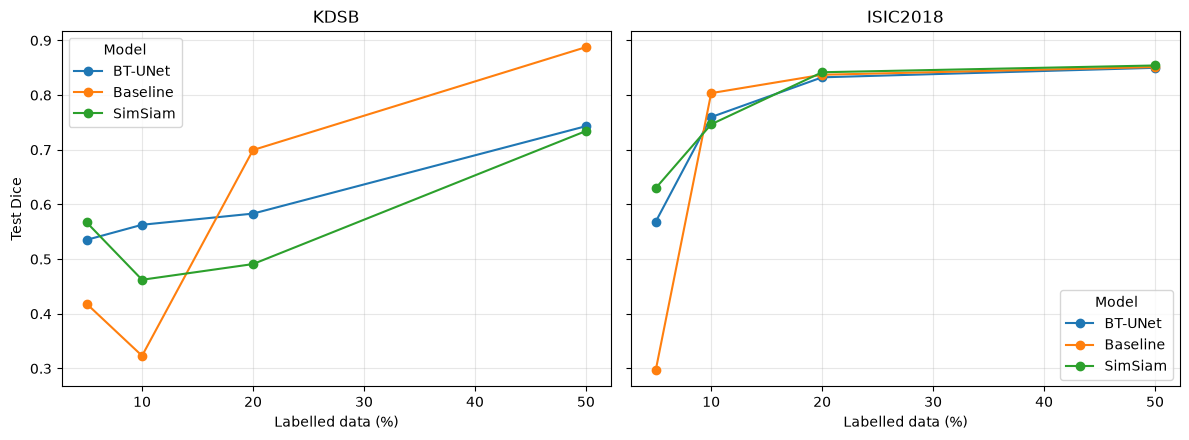

In [9]:
if not results_df.empty:
    METRIC = "Test Dice"
    datasets = list(results_df["Dataset"].unique())

    for ds in datasets:
        sub = results_df[results_df["Dataset"] == ds]
        cols = ["Model", "Variant"] if sub["Variant"].nunique() > 1 else "Model"
        pivot = sub.pivot_table(index="Label Fraction (%)", columns=cols,
                                values=METRIC, aggfunc="mean")
        print(f"\n{'='*50}\n{ds} — {METRIC}\n{'='*50}")
        display(pivot)

        base_col = ("Baseline", "base") if isinstance(cols, list) else "Baseline"
        if base_col in pivot.columns:
            delta = pivot.drop(columns=base_col).sub(pivot[base_col], axis=0)
            print("Improvement over supervised baseline:")
            display(delta)

    # Side-by-side plot, one panel per dataset with a shared y-axis.
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 4.5),
                             sharey=True, squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = results_df[results_df["Dataset"] == ds]
        cols = ["Model", "Variant"] if sub["Variant"].nunique() > 1 else "Model"
        pivot = sub.pivot_table(index="Label Fraction (%)", columns=cols,
                                values=METRIC, aggfunc="mean")
        pivot.plot(marker="o", ax=ax)
        ax.set_title(ds)
        ax.set_xlabel("Labelled data (%)")
        ax.grid(alpha=0.3)
    axes[0][0].set_ylabel(METRIC)
    plt.tight_layout()
    plt.show()


## Fold Spread

Only meaningful when `INCLUDE_KINDS` contains `"fold"`. Shows mean and standard
deviation across folds, which is what you would report alongside the ensemble number.


In [10]:
fold_rows = results_df[results_df["Kind"] == "fold"] if not results_df.empty else pd.DataFrame()

if fold_rows.empty:
    print('No per-fold models evaluated. Add "fold" to INCLUDE_KINDS and re-run.')
else:
    non_metric = {"Dataset", "Model", "Variant", "Label Fraction (%)", "Kind", "Fold", "Val Source", "File"}
    metric_cols = [c for c in fold_rows.columns if c not in non_metric and fold_rows[c].dtype != object]
    summary = fold_rows.groupby(["Dataset", "Model", "Variant", "Label Fraction (%)"])[metric_cols].agg(["mean", "std"])
    display(summary)
    p = os.path.join(RESULTS_DIR, "evaluation_fold_summary.csv")
    summary.to_csv(p)
    print(f"Saved {p}")


Train Accuracy        Train Precision  \
                                               mean    std            mean   
Dataset  Model    Label Fraction (%)                                         
ISIC2018 BT-UNet  5                          0.7094 0.0847          0.4584   
                  10                         0.9012 0.1435          0.8374   
                  20                         0.9790 0.0068          0.9705   
                  50                         0.9773 0.0049          0.9653   
         Baseline 5                          0.7370 0.1106          0.4187   
                  10                         0.9761 0.0055          0.9377   
                  20                         0.9930 0.0016          0.9850   
                  50                         0.9896 0.0023          0.9786   
         SimSiam  5                          0.7558 0.1407          0.5417   
                  10                         0.8760 0.1507          0.7589   
                  20                         0.9938 0.0009          0.9867   
                  50                         0.9887 0.0033          0.9792   
KDSB     BT-UNet  5                          0.6877 0.1119          0.3274   
                  10                         0.7492 0.0182          0.3687   
                  20                         0.8298 0.0420          0.4577   
                  50                         0.8687 0.1277          0.6442   
         Baseline 5                          0.7663 0.1841          0.3962   
                  10                         0.7839 0.0295          0.3128   
                  20                         0.9238 0.0631          0.6584   
                  50                         0.9848 0.0064          0.9373   
         SimSiam  5                          0.8255 0.0443          0.4640   
                  10                         0.8309 0.0620          0.5133   
                  20                         0.8436 0.0342          0.4682   
                  50                         0.9231 0.0614          0.7395   

                                            Train Recall        Train MeanIoU  \
                                        std         mean    std          mean   
Dataset  Model    Label Fraction (%)                                            
ISIC2018 BT-UNet  5                  0.1167       0.8976 0.0208        0.5324   
                  10                 0.2455       0.8965 0.0668        0.8177   
                  20                 0.0100       0.9402 0.0243        0.9437   
                  50                 0.0080       0.9380 0.0150        0.9392   
         Baseline 5                  0.4522       0.2751 0.4034        0.4273   
                  10                 0.0102       0.9632 0.0147        0.9372   
                  20                 0.0026       0.9855 0.0050        0.9809   
                  50                 0.0061       0.9775 0.0042        0.9717   
         SimSiam  5                  0.2436       0.8899 0.0680        0.6033   
                  10                 0.2855       0.9150 0.0845        0.7864   
                  20                 0.0018       0.9872 0.0023        0.9831   
                  50                 0.0044       0.9733 0.0102        0.9694   
KDSB     BT-UNet  5                  0.0768       0.8975 0.0856        0.4746   
                  10                 0.0224       0.9077 0.0479        0.5320   
                  20                 0.0871       0.8949 0.0244        0.6190   
                  50                 0.2611       0.9563 0.0135        0.7333   
         Baseline 5                  0.2273       0.5414 0.4202        0.5113   
                  10                 0.0400       0.4008 0.2114        0.4864   
                  20                 0.2120       0.8288 0.3367        0.7690   
                  50                 0.0390       0.9690 0.0093        0.9460   
         SimSiam  5                  0.0938       0.6479 0.1306    

Saved results/evaluation_fold_summary.csv
